# Daily cash and payments: the numbers

This notebook is the source of truth for every number in the README, on the portfolio card and in `powerbi/06-checks.md`.
It reads the star schema that `load.py` built in PostgreSQL. Run `docker compose up -d` and `python load.py` first.

The rules (cash date, report date, late, never paid) live in one place, `sql/2_rules.sql`. This notebook only adds them up.
Every client value (name, currency, colours, the late threshold, the check month) comes from `config/client.yaml` through `load_config()`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

sys.path.append("..")
from config import load_config

cfg = load_config()
NAME, CUR, DEC = cfg["client"]["name"], cfg["client"]["currency"], cfg["client"]["decimals"]
COLOURS = cfg["report"]["colours"]
MAIN, SECOND = COLOURS["data"][0], COLOURS["data"][2]
DOCS = Path("../docs")
conn = psycopg.connect(cfg["db_url"])


def q(sql):
    with conn.cursor() as cur:
        cur.execute(sql)
        return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])


def money(x):
    return f"{CUR} {x:,.{DEC}f}"


def short(x):
    return f"{CUR} {x / 1e6:.2f} million" if x >= 1e6 else money(x)


fact = q("""
    select f.*, m.payment_method, m.sort_order, s.state, s.region
    from mart.fact_instalment f
    join mart.dim_payment_method m using (payment_type)
    join mart.dim_state s using (customer_state)
""")
fact["amount"] = fact["amount"].astype(float)
fact["cash_date"] = pd.to_datetime(fact["cash_date"])
received_rows = fact[fact["status"] == "Received"]
report_date = received_rows["cash_date"].max()

print(f"{NAME}: {len(fact):,} instalment rows, report date {report_date:%d %b %Y}")

Sample online store: 296,425 instalment rows, report date 03 Sep 2018


## 1. Every total matches the source

Read the payments input file straight from `data/input`, without the database, and compare it with the model.

In [2]:
source = pd.read_csv(cfg["input_dir"] / cfg["inputs"]["payments"])

payments = fact["payment_id"].nunique()
total = fact["amount"].sum()
print(f"payments: source {len(source):,}, model {payments:,}")
print(f"money:    source {money(source['payment_value'].sum())}, model {money(total)}")
assert payments == len(source)
assert round(total, DEC) == round(source["payment_value"].sum(), DEC)

payments: source 103,886, model 103,886


money:    source BRL 16,008,872.12, model BRL 16,008,872.12


## 2. Cash in, still due and never paid

On the report date: what has come in, what card instalments are still to come, and what was never paid.

In [3]:
by_status = (fact.groupby("status").agg(amount=("amount", "sum"), payments=("payment_id", "nunique"))
             .reindex(["Received", "Due", "Never paid"], fill_value=0))
by_status["share_%"] = (by_status["amount"] / total * 100).round(1)
display(by_status.round(DEC))

received = by_status.loc["Received", "amount"]
due = by_status.loc["Due", "amount"]
never_paid = by_status.loc["Never paid", "amount"]
due_rows = fact[fact["status"] == "Due"]
if len(due_rows):
    print(f"still due: {money(due)} on {due_rows['payment_id'].nunique():,} payments, "
          f"the last instalment on {due_rows['cash_date'].max():%d %b %Y}")
else:
    print("nothing still due")

,amount,payments,share_%
status,,,
Received,14415391.61,103711,90.0
Due,1556350.74,11648,9.7
Never paid,37129.77,175,0.2


still due: BRL 1,556,350.74 on 11,648 payments, the last instalment on 03 May 2020


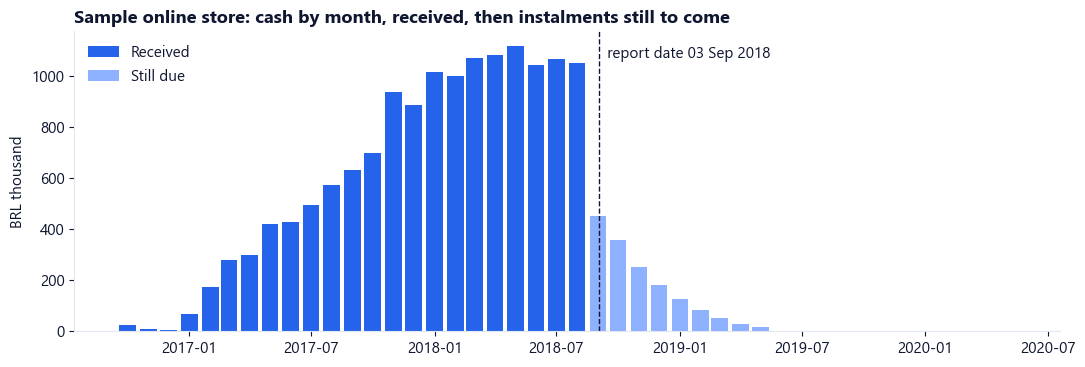

In [4]:
plt.rcParams.update({"font.family": "Segoe UI", "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.edgecolor": COLOURS["line"], "text.color": COLOURS["text"],
                     "axes.labelcolor": COLOURS["text"], "xtick.color": COLOURS["text"], "ytick.color": COLOURS["text"]})

monthly = (fact[fact["status"] != "Never paid"]
           .assign(month=lambda d: d["cash_date"].dt.to_period("M").dt.to_timestamp())
           .pivot_table(index="month", columns="status", values="amount", aggfunc="sum", fill_value=0)
           .reindex(columns=["Received", "Due"], fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(monthly.index, monthly["Received"] / 1e3, width=25, color=MAIN, label="Received")
ax.bar(monthly.index, monthly["Due"] / 1e3, width=25, color=SECOND, label="Still due")
ax.axvline(report_date, color=COLOURS["text"], linewidth=1, linestyle="--")
ax.text(report_date, ax.get_ylim()[1] * 0.95, f"  report date {report_date:%d %b %Y}", va="top")
ax.set_ylabel(f"{CUR} thousand")
ax.legend(frameon=False, loc="upper left")
ax.set_title(f"{NAME}: cash by month, received, then instalments still to come", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "cash-by-month.png", dpi=150)

## 3. Where the cash in comes from

Share of the money received (status Received), by payment method and by the customer's region.

In [5]:
by_method = (received_rows.groupby(["sort_order", "payment_method"])
               .agg(cash_in=("amount", "sum"))
               .reset_index(level=0, drop=True))
by_method["share_%"] = (by_method["cash_in"] / received * 100).round(1)

by_region = received_rows.groupby("region").agg(cash_in=("amount", "sum")).sort_values("cash_in", ascending=False)
by_region["share_%"] = (by_region["cash_in"] / received * 100).round(1)

display(by_method.round(DEC), by_region.round(DEC))

,cash_in,share_%
payment_method,,
Credit card,10975162.62,76.1
Boleto (bank slip),2865633.94,19.9
Voucher,356605.26,2.5
Debit card,217989.79,1.5


,cash_in,share_%
region,,
Southeast,9342516.46,64.8
South,2085427.96,14.5
Northeast,1686567.07,11.7
Central-West,922523.27,6.4
North,378356.85,2.6


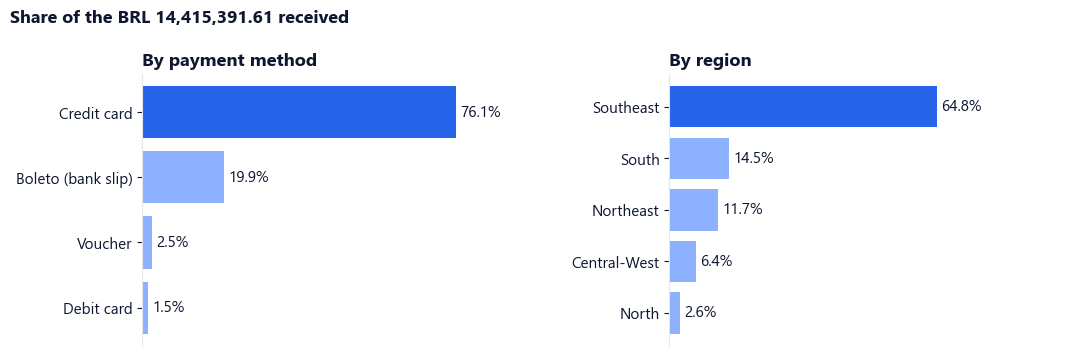

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, data, title in [(axes[0], by_method["share_%"], "By payment method"),
                        (axes[1], by_region["share_%"], "By region")]:
    data = data.sort_values()
    ax.barh(data.index, data.values, color=[SECOND] * (len(data) - 1) + [MAIN])
    for y, v in enumerate(data.values):
        ax.text(v + 1, y, f"{v:.1f}%", va="center")
    ax.set_xlim(0, 100)
    ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)
    ax.set_title(title, loc="left", fontweight="bold")
fig.suptitle(f"Share of the {money(received)} received", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "where-the-money-comes-from.png", dpi=150)

## 4. Late payments

A payment is late when it was confirmed more than `rules.late_after_days` days after the order was placed (`sql/2_rules.sql`, rule 3).
The rate is out of the payments that were confirmed: a payment that was never paid cannot be late.

In [7]:
LATE_DAYS = cfg["rules"]["late_after_days"]
confirmed = fact[(fact["instalment_no"] == 1) & (fact["status"] == "Received")]  # one row per confirmed payment
late = (confirmed.groupby(["sort_order", "payment_method"])
        .agg(confirmed=("payment_id", "size"), late=("is_late", "sum"))
        .reset_index(level=0, drop=True))
late["late_%"] = (late["late"] / late["confirmed"] * 100).round(1)
late["late_amount"] = (fact[fact["is_late"]].groupby("payment_method")["amount"].sum()
                       .reindex(late.index, fill_value=0).round(DEC))
display(late)

payments_confirmed = len(confirmed)
late_payments = int(confirmed["is_late"].sum())
late_amount = fact.loc[fact["is_late"], "amount"].sum()
late_rate = late_payments / payments_confirmed * 100
top_late_method = late["late"].idxmax()
top_late_share = late["late"].max() / late_payments * 100 if late_payments else 0
print(f"late (more than {LATE_DAYS} days): {late_payments:,} of {payments_confirmed:,} confirmed payments "
      f"({late_rate:.1f}%), {money(late_amount)}; {top_late_share:.0f}% of them are {top_late_method}")

,confirmed,late,late_%,late_amount
payment_method,,,,
Credit card,76739,429,0.6,88672.94
Boleto (bank slip),19754,1796,9.1,258740.57
Voucher,5689,47,0.8,3093.70
Debit card,1529,29,1.9,3183.63


late (more than 3 days): 2,301 of 103,711 confirmed payments (2.2%), BRL 353,690.84; 78% of them are Boleto (bank slip)


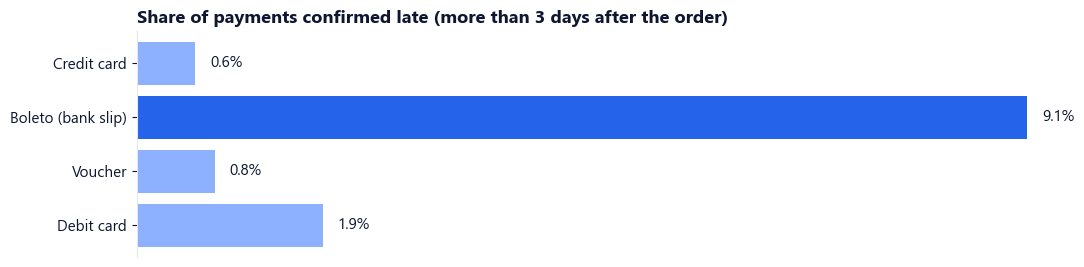

In [8]:
data = late["late_%"][::-1]
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.barh(data.index, data.values, color=[MAIN if v == data.max() else SECOND for v in data.values])
for y, v in enumerate(data.values):
    ax.text(v + 0.15, y, f"{v:.1f}%", va="center")
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Share of payments confirmed late (more than {LATE_DAYS} days after the order)", loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "late-payments.png", dpi=150)

## 5. The numbers for the Power BI checks

What each card and visual must show with no slicer selected, and with one example filter
(the date slicer set to the check month, `report.check_month`, on the Daily cash page). `powerbi/06-checks.md` copies these.

In [9]:
cards = pd.Series({
    "Cash In": f"{received:,.{DEC}f}",
    "Payments Confirmed": f"{payments_confirmed:,}",
    "Late Payments": f"{late_payments:,}",
    "Late Rate %": f"{late_rate:.1f}%",
    "Still Due": f"{due:,.{DEC}f}",
    "Never Paid": f"{never_paid:,.{DEC}f}",
    "Late Amount": f"{late_amount:,.{DEC}f}",
    "Report Date": f"{report_date:%d %b %Y}",
    "Payments (all)": f"{payments:,}",
    "Total Paid": f"{total:,.{DEC}f}",
}, name="no slicer")

check_month = pd.Period(cfg["report"]["check_month"], freq="M")
month = fact[fact["cash_date"].dt.to_period("M") == check_month]
month_confirmed = month[(month["instalment_no"] == 1) & (month["status"] == "Received")]
month_cards = pd.Series({
    "Cash In": f"{month.loc[month['status'] == 'Received', 'amount'].sum():,.{DEC}f}",
    "Payments Confirmed": f"{len(month_confirmed):,}",
    "Late Payments": f"{int(month_confirmed['is_late'].sum()):,}",
    "Late Rate %": f"{month_confirmed['is_late'].mean() * 100:.1f}%",
}, name=check_month.strftime("%b %Y"))

due_by_month = (fact[fact["status"] == "Due"].groupby(fact["cash_date"].dt.strftime("%Y-%m"))["amount"].sum().round(DEC))
display(pd.concat([cards, month_cards], axis=1).fillna(""), due_by_month.head(4))

,no slicer,May 2018
Cash In,"14,415,391.61","1,117,998.16"
Payments Confirmed,"103,711","7,334"
Late Payments,"2,301",99
Late Rate %,2.2%,1.3%
Still Due,"1,556,350.74",
Never Paid,"37,129.77",
Late Amount,"353,690.84",
Report Date,03 Sep 2018,
Payments (all),"103,886",
Total Paid,"16,008,872.12",


cash_date
2018-09    451045.10
2018-10    358412.19
2018-11    252853.90
2018-12    180381.17
Name: amount, dtype: float64

## 6. The sentences

The README and the portfolio card quote these lines as they are printed here.

In [10]:
top_method, top_region = by_method["share_%"].idxmax(), by_region["share_%"].idxmax()
print(f"{payments:,} payments: {by_method.loc[top_method, 'share_%']:.0f}% of the cash in arrived by {top_method.lower()}, "
      f"and {short(due)} was still due on instalments.")
print(f"{top_region} brought in {by_region.loc[top_region, 'share_%']:.0f}% of the cash.")
print(f"{late_payments:,} payments ({late_rate:.1f}%) were confirmed late; {top_late_share:.0f}% of them were {top_late_method.lower()}.")
print(f"{money(never_paid)} was never paid.")

103,886 payments: 76% of the cash in arrived by credit card, and BRL 1.56 million was still due on instalments.
Southeast brought in 65% of the cash.
2,301 payments (2.2%) were confirmed late; 78% of them were boleto (bank slip).
BRL 37,129.77 was never paid.
